In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
f1_score, roc_auc_score, confusion_matrix,
classification_report)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
import joblib

In [8]:
df = pd.read_csv(r"/Users/thotathrishika/Data/Titanic-Survival-prediction/data/Titanic-Dataset.csv")

print(df.head())
print(df.shape)
print(df.info())
print(df.isnull().sum())

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch Embarked            Ticket     Fare Cabin  PassengerId  Pclass  \
0      0        S         A/5 21171   7.2500   NaN            1       3   
1      0        C          PC 17599  71.2833   C85            2       1   
2      0        S  STON/O2. 3101282   7.9250   NaN            3       3   
3      0        S            113803  53.1000  C123            4       1   
4      0        S            373450   8.0500   NaN            5       3   

   Survived  
0         0  
1         1  
2         1  
3         1  
4         0  
(8

Survived
0    549
1    342
Name: count, dtype: int64


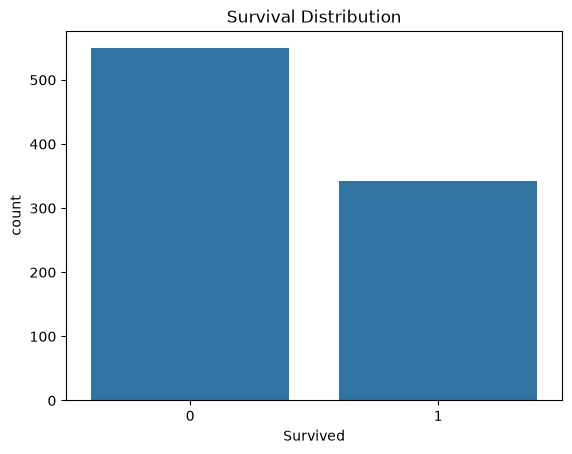

In [9]:
print(df["Survived"].value_counts())

sns.countplot(data=df, x="Survived")
plt.title("Survival Distribution")
plt.show()

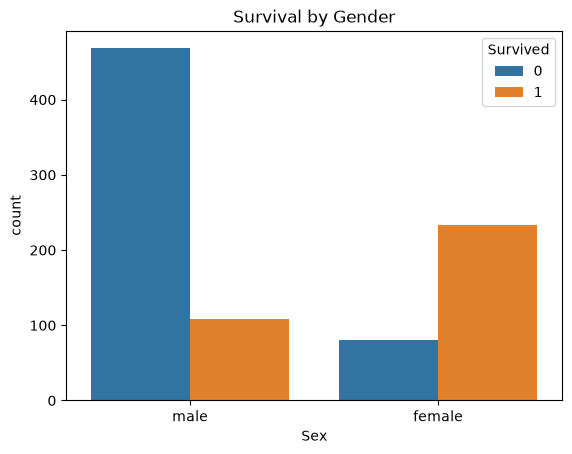

In [10]:
sns.countplot(data=df, x="Sex", hue="Survived")
plt.title("Survival by Gender")
plt.show()

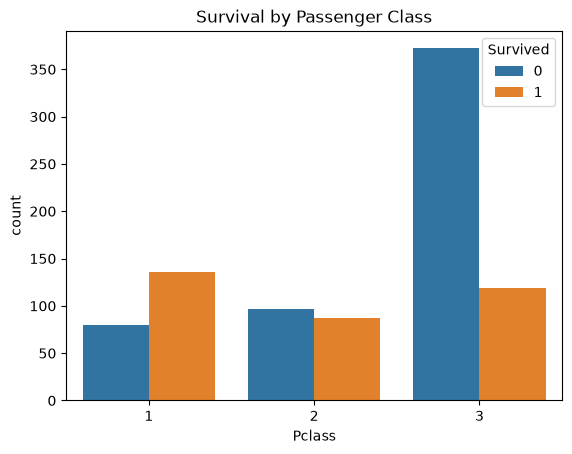

In [11]:
sns.countplot(data=df, x="Pclass", hue="Survived")
plt.title("Survival by Passenger Class")
plt.show()

In [12]:
features = ["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]

X = df[features]
y = df["Survived"]

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (712, 7)
Testing data: (179, 7)


In [14]:
numeric_features = ["Pclass", "Age", "SibSp", "Parch", "Fare"]
categorical_features = ["Sex", "Embarked"]

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

In [15]:
logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

In [16]:
decision_tree = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(random_state=42, max_depth=5))
])

In [17]:
random_forest = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(n_estimators=300, random_state=42))
])

In [18]:
gradient_boosting = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingClassifier(random_state=42))
])

In [19]:
xgb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42
    ))
])

In [23]:
ml_models = {
    "Logistic Regression": logistic_model,
    "Decision Tree": decision_tree,
    "Random Forest": random_forest,
    "Gradient Boosting": gradient_boosting,
    "XGBoost": xgb_model
}

ml_results = []

for name, model in ml_models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    ml_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

ml_results_df = pd.DataFrame(ml_results)
print(ml_results_df)

                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
0  Logistic Regression  0.804469   0.793103  0.666667  0.724409  0.843742
1        Decision Tree  0.765363   0.754717  0.579710  0.655738  0.797101
2        Random Forest  0.810056   0.796610  0.681159  0.734375  0.828590
3    Gradient Boosting  0.798883   0.789474  0.652174  0.714286  0.817918
4              XGBoost  0.798883   0.779661  0.666667  0.718750  0.808103


                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
2        Random Forest  0.810056   0.796610  0.681159  0.734375  0.828590
0  Logistic Regression  0.804469   0.793103  0.666667  0.724409  0.843742
4              XGBoost  0.798883   0.779661  0.666667  0.718750  0.808103
3    Gradient Boosting  0.798883   0.789474  0.652174  0.714286  0.817918
1        Decision Tree  0.765363   0.754717  0.579710  0.655738  0.797101


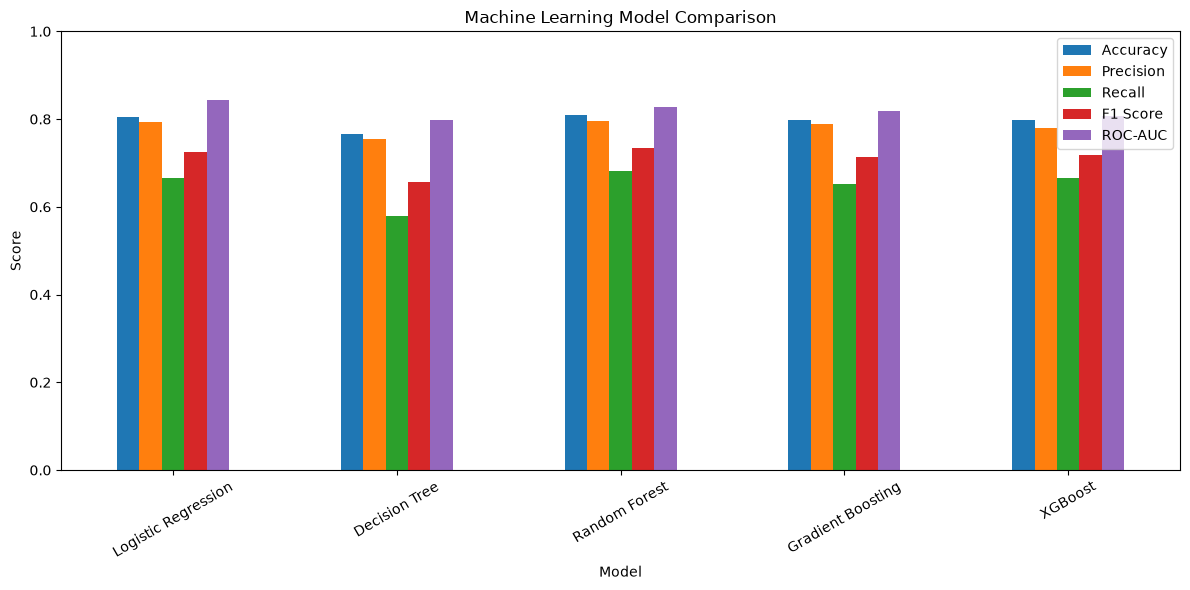

In [21]:
print(ml_results_df.sort_values(by="F1 Score", ascending=False))

ml_results_df.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]
].plot(kind="bar", figsize=(12, 6))

plt.title("Machine Learning Model Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [25]:
dl_numeric = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

dl_categorical = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

dl_preprocessor = ColumnTransformer([
    ("num", dl_numeric, numeric_features),
    ("cat", dl_categorical, categorical_features)
])

X_train_dl = dl_preprocessor.fit_transform(X_train)
X_test_dl = dl_preprocessor.transform(X_test)

print(X_train_dl.shape)

(712, 10)


In [27]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

ann_model = Sequential([
    Dense(64, activation="relu", input_shape=(X_train_dl.shape[1],)),
    Dropout(0.30),
    Dense(32, activation="relu"),
    Dropout(0.20),
    Dense(16, activation="relu"),
    Dense(1, activation="sigmoid")
])

ann_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

ann_history = ann_model.fit(
    X_train_dl,
    y_train,
    validation_split=0.20,
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/keras/src/layers/core/dense.py:102: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.6186 - loss: 0.6690 - val_accuracy: 0.6434 - val_loss: 0.6414
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6573 - loss: 0.6149 - val_accuracy: 0.7133 - val_loss: 0.5897
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7188 - loss: 0.5741 - val_accuracy: 0.7692 - val_loss: 0.5467
Epoch 4/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7540 - loss: 0.5397 - val_accuracy: 0.7622 - val_loss: 0.5145
Epoch 5/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7750 - loss: 0.5087 - val_accuracy: 0.7832 - val_loss: 0.4913
Epoch 6/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7961 - loss: 0.4835 - val_accuracy: 0.8112 - val_loss: 0.4734
Epoch 7/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7979 - loss: 0.4745 - val_accuracy: 0.7972 - val_loss: 0.4600
Epoch 8/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7926 - loss: 0.4698 - val_accuracy: 0.8112 - val_loss: 0.4533
Ep

In [28]:
ann_prob = ann_model.predict(X_test_dl).ravel()
ann_pred = (ann_prob >= 0.5).astype(int)

ann_results = {
    "Model": "ANN",
    "Accuracy": accuracy_score(y_test, ann_pred),
    "Precision": precision_score(y_test, ann_pred),
    "Recall": recall_score(y_test, ann_pred),
    "F1 Score": f1_score(y_test, ann_pred),
    "ROC-AUC": roc_auc_score(y_test, ann_prob)
}

print(ann_results)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
{'Model': 'ANN', 'Accuracy': 0.7821229050279329, 'Precision': 0.75, 'Recall': 0.6521739130434783, 'F1 Score': 0.6976744186046512, 'ROC-AUC': 0.8541501976284585}


In [29]:
X_train_cnn = X_train_dl.reshape(X_train_dl.shape[0], X_train_dl.shape[1], 1)
X_test_cnn = X_test_dl.reshape(X_test_dl.shape[0], X_test_dl.shape[1], 1)

In [30]:
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten

cnn_model = Sequential([
    Conv1D(
        32,
        kernel_size=3,
        activation="relu",
        input_shape=(X_train_cnn.shape[1], 1)
    ),
    MaxPooling1D(pool_size=2),
    Conv1D(64, kernel_size=3, activation="relu"),
    Flatten(),
    Dense(32, activation="relu"),
    Dropout(0.30),
    Dense(1, activation="sigmoid")
])

cnn_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

cnn_history = cnn_model.fit(
    X_train_cnn,
    y_train,
    validation_split=0.20,
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.6749 - loss: 0.6309 - val_accuracy: 0.7343 - val_loss: 0.5729
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7399 - loss: 0.5358 - val_accuracy: 0.7972 - val_loss: 0.4964
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7786 - loss: 0.4937 - val_accuracy: 0.7972 - val_loss: 0.4711
Epoch 4/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7803 - loss: 0.4816 - val_accuracy: 0.7902 - val_loss: 0.4654
Epoch 5/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7909 - loss: 0.4722 - val_accuracy: 0.7902 - val_loss: 0.4620
Epoch 6/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7979 - loss: 0.4614 - val_accuracy: 0.8042 - val_loss: 0.4574
Epoch 7/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8032 - loss: 0.4671 - val_accuracy: 0.8112 - val_loss: 0.4580
Epoch 8/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8049 - loss: 0.4522 - val_accuracy: 0.8042 - val_loss: 0.4573
Ep

In [31]:
cnn_prob = cnn_model.predict(X_test_cnn).ravel()
cnn_pred = (cnn_prob >= 0.5).astype(int)

cnn_results = {
    "Model": "1D CNN",
    "Accuracy": accuracy_score(y_test, cnn_pred),
    "Precision": precision_score(y_test, cnn_pred),
    "Recall": recall_score(y_test, cnn_pred),
    "F1 Score": f1_score(y_test, cnn_pred),
    "ROC-AUC": roc_auc_score(y_test, cnn_prob)
}

print(cnn_results)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
{'Model': '1D CNN', 'Accuracy': 0.7932960893854749, 'Precision': 0.7424242424242424, 'Recall': 0.7101449275362319, 'F1 Score': 0.725925925925926, 'ROC-AUC': 0.8461133069828723}


In [32]:
dl_results_df = pd.DataFrame([ann_results, cnn_results])

all_results = pd.concat(
    [ml_results_df, dl_results_df],
    ignore_index=True
)

print(all_results)

                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
0  Logistic Regression  0.804469   0.793103  0.666667  0.724409  0.843742
1        Decision Tree  0.765363   0.754717  0.579710  0.655738  0.797101
2        Random Forest  0.810056   0.796610  0.681159  0.734375  0.828590
3    Gradient Boosting  0.798883   0.789474  0.652174  0.714286  0.817918
4              XGBoost  0.798883   0.779661  0.666667  0.718750  0.808103
5                  ANN  0.782123   0.750000  0.652174  0.697674  0.854150
6               1D CNN  0.793296   0.742424  0.710145  0.725926  0.846113


                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
2        Random Forest  0.810056   0.796610  0.681159  0.734375  0.828590
6               1D CNN  0.793296   0.742424  0.710145  0.725926  0.846113
0  Logistic Regression  0.804469   0.793103  0.666667  0.724409  0.843742
4              XGBoost  0.798883   0.779661  0.666667  0.718750  0.808103
3    Gradient Boosting  0.798883   0.789474  0.652174  0.714286  0.817918
5                  ANN  0.782123   0.750000  0.652174  0.697674  0.854150
1        Decision Tree  0.765363   0.754717  0.579710  0.655738  0.797101


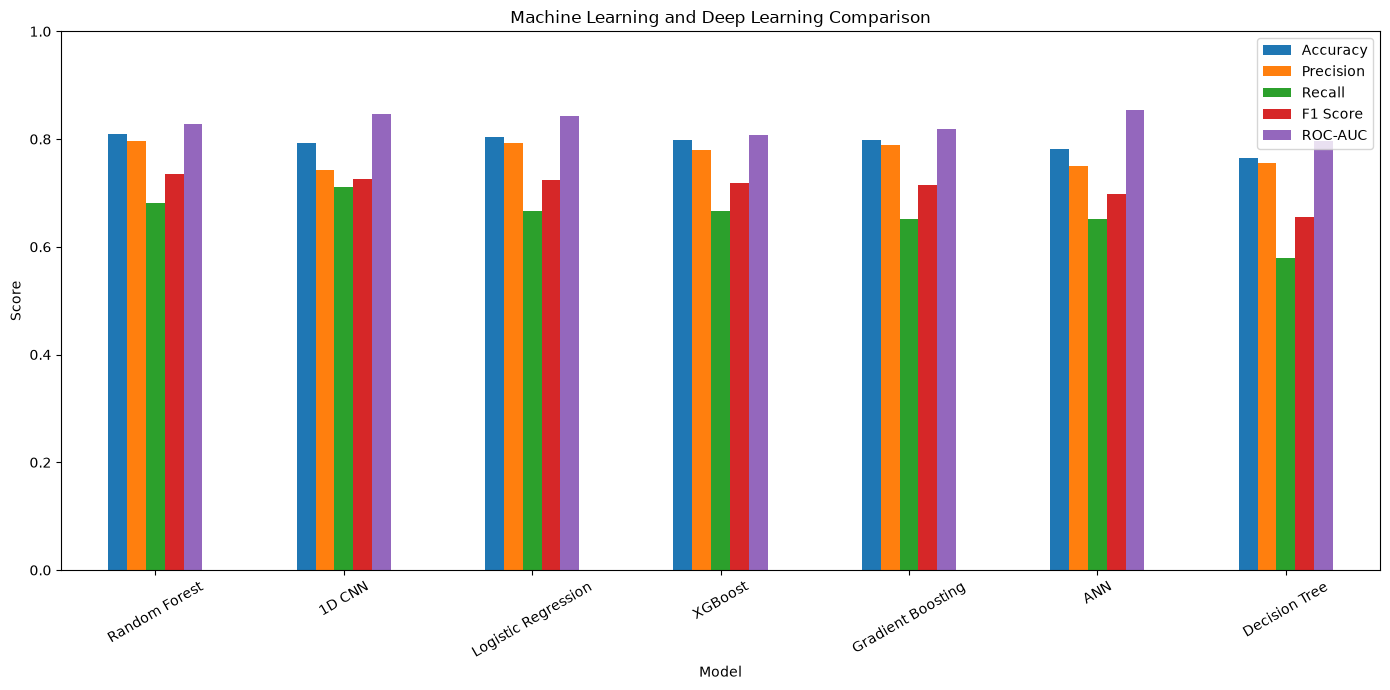

In [33]:
all_results = all_results.sort_values(
    by="F1 Score",
    ascending=False
)

print(all_results)

all_results.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]
].plot(kind="bar", figsize=(14, 7))

plt.title("Machine Learning and Deep Learning Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [34]:
best_model_name = all_results.iloc[0]["Model"]

print("Best model based on F1 Score:", best_model_name)

Best model based on F1 Score: Random Forest


In [35]:
best_ml_model = ml_models[best_model_name]

joblib.dump(
    best_ml_model,
    "titanic_best_model.pkl"
)

['titanic_best_model.pkl']